# Autonomous Navigation System for Thymio Robot

## Project Report

This report presents a complete autonomous navigation system for the Thymio robot, implementing computer vision-based localization, path planning using A* algorithm, and real-time path following with Kalman filtering and pure pursuit control.

---

## Table of Contents

1. [Introduction](#introduction)
2. [System Architecture](#system-architecture)
3. [Computer Vision Pipeline](#computer-vision-pipeline)
4. [Path Planning with A*](#path-planning-with-a)
5. [Motion Control System](#motion-control-system)
6. [State Estimation with Kalman Filter](#state-estimation-with-kalman-filter)
7. [Pure Pursuit Path Following](#pure-pursuit-path-following)
8. [Real-time Vision Tracking](#real-time-vision-tracking)
9. [Conclusion](#conclusion)

---


## Introduction

This project implements a complete autonomous navigation system for the Thymio robot that enables it to navigate from a starting position to a goal while avoiding obstacles. The system combines several advanced robotics techniques:

- **Computer Vision**: Real-time detection and tracking of the robot, goal, and obstacles using color-based segmentation
- **Path Planning**: A* algorithm for optimal path calculation in a grid-based environment
- **State Estimation**: Extended Kalman Filter (EKF) for robust pose estimation combining odometry and vision
- **Path Following**: Pure pursuit algorithm for smooth trajectory tracking
- **Obstacle Avoidance**: Reactive obstacle avoidance with dynamic path recalculation

The system operates in a structured environment where the robot (marked with green), goal (purple square), and obstacles (yellow) are detected through a top-down camera view. The entire pipeline is implemented in Python using OpenCV for vision processing, NumPy for numerical computations, and tdmclient for robot communication.


### Credits

Kalman filter + Pure Pursuit Algorithm : **Arthur Keunecke**
<br>
Global navigation : **Tom Herrmann**
<br>
Vision + Local Avoidance : **Justin Decaillet**
<br>
Motion Control : **All three members**

## System Architecture

The system follows a sequential pipeline that can be divided into three main phases:

1. **Initialization Phase**: Computer vision detects all elements in the environment
2. **Planning Phase**: A* algorithm calculates the optimal path
3. **Execution Phase**: Robot follows the path using Kalman filter and pure pursuit

The following diagram illustrates the complete workflow:

```
Camera Input
    ↓
Vision Recognition (vision_recognition.py)
    ├─→ Board Detection & Homography
    ├─→ Thymio Detection (Green)
    ├─→ Goal Detection (Purple/Yellow)
    └─→ Obstacle Detection (Yellow)
    ↓
Navigation Map Construction (main.py)
    ↓
A* Path Planning (global_navigation.py)
    ↓
Path Following Loop (motion_control.py)
    ├─→ Vision Tracking (vision_tracker.py)
    ├─→ Kalman Filter (kalmanpy.py)
    ├─→ Pure Pursuit (pure_pursuit.py)
    └─→ Motor Control
```

Let's examine each component in detail.


## Computer Vision Pipeline

### File: `vision_recognition.py`

The computer vision module is responsible for the initial detection and mapping of the environment. It processes a single camera frame to identify the robot, goal, and obstacles, then constructs an occupancy grid for path planning.

**Key Functions:**
- `detect_board_and_corners()`: Detects the white board and black corner markers
- `detect_thymio_green()`: Identifies the Thymio robot by its green patch
- `detect_thymio_orientation()`: Determines robot orientation using a blue directional marker
- `detect_goal_purple()`: Locates the goal (purple/yellow square)
- `build_red_occupancy()`: Creates an occupancy grid from yellow obstacles
- `run_recognition()`: Main pipeline function that orchestrates all detection steps


In [1]:
# Import necessary modules
import sys
import os
sys.path.append('.')

from vision_recognition import (
    detect_board_and_corners,
    detect_thymio_green,
    detect_thymio_orientation,
    detect_goal_purple,
    build_red_occupancy,
    run_recognition,
    RecognitionResult
)


In [2]:
# Key code sections from vision_recognition.py

# 1. Board detection and homography calculation

def detect_board_and_corners(frame_bgr):
    """Detects main white surface (board) and finds black squares in corners."""
    # Convert to grayscale and threshold
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, white_mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Find largest white contour (the board)
    contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    board_cnt = max(contours, key=cv2.contourArea)
    
    # Search for black squares in each corner ROI
    # Returns 4 corner points: TL, TR, BR, BL
    return corner_points


# 2. Thymio detection with orientation

def detect_thymio_green(warped_bgr):
    """Detects Thymio green patch from rectified image."""
    hsv = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2HSV)
    lower_green = np.array([50, 40, 67], np.uint8)
    upper_green = np.array([85, 160, 187], np.uint8)
    mask = cv2.inRange(hsv, lower_green, upper_green)
    
    # Find largest contour and calculate centroid
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contours, key=cv2.contourArea)
    M = cv2.moments(cnt)
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    return (cx, cy), mask

def detect_thymio_orientation(warped_bgr, thymio_center):
    """Detects orientation using blue directional marker near Thymio center."""
    # Search for blue pixels near the green patch
    # Calculate angle from center to blue marker
    angle = math.atan2(dy, dx)  # Angle in radians
    return angle, marker_position


# 3. Occupancy grid construction

def build_red_occupancy(warped_hsv, cell_size_px=1):
    """Builds yellow occupancy grid and returns occupied cells."""
    # Yellow range: H=19, S=85, V=218 ± tolerances
    lower_yellow = np.array([10, 55, 178])
    upper_yellow = np.array([40, 115, 255])
    mask_yellow = cv2.inRange(warped_hsv, lower_yellow, upper_yellow)
    
    # Dilate obstacles to create safety margin (Thymio size)
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (16, 16))
    occ_grid = cv2.dilate(mask_yellow, dilation_kernel, iterations=1)
    
    # Downsample to coarse grid for path planning
    return occ_grid_fine, occ_grid_coarse, obstacle_cells


### Main Recognition Function

The `run_recognition()` function orchestrates the entire vision pipeline. It captures a frame, applies perspective transformation, and performs all detections in sequence. The result is a `RecognitionResult` dataclass containing all detected information.


In [3]:
# Main recognition pipeline

def run_recognition(cam_index=1, board_width_m=0.84, board_height_m=0.89, 
                    resolution_m=0.01, display=False) -> RecognitionResult:
    """Complete pipeline: capture -> homography -> Thymio + obstacles."""
    
    # 1. Capture and stabilize autofocus
    cap = cv2.VideoCapture(cam_index)
    cap.set(cv2.CAP_PROP_AUTOFOCUS, 1)
    for _ in range(10):
        cap.read()  # Let autofocus stabilize
    ret, frame = cap.read()
    
    # 2. Detect board and compute homography
    src_pts = detect_board_and_corners(frame)
    width_px = int(board_width_m / resolution_m)
    height_px = int(board_height_m / resolution_m)
    dst_pts = np.array([[0, 0], [width_px-1, 0], 
                        [width_px-1, height_px-1], [0, height_px-1]])
    homography = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(frame, homography, (width_px, height_px))
    
    # 3. Detect all elements
    thymio_pos, thymio_mask = detect_thymio_green(warped)
    thymio_orientation, _ = detect_thymio_orientation(warped, thymio_pos)
    goal_pos, goal_mask = detect_goal_purple(warped)
    occ_grid_fine, occ_grid_coarse, obstacles, _ = build_red_occupancy(warped_hsv)
    
    # 4. Convert to grid coordinates
    thymio_cell = locate_thymio_cells(thymio_mask, thymio_pos, occ_grid_fine.shape)
    goal_cell = locate_thymio_cells(goal_mask, goal_pos, occ_grid_fine.shape)
    
    return RecognitionResult(
        frame_bgr=frame,
        warped_bgr=warped,
        homography=homography,
        thymio_cell=thymio_cell,
        thymio_orientation=thymio_orientation,
        goal_cell=goal_cell,
        occ_grid_coarse=occ_grid_coarse,  #...# 
        )


## Path Planning with A*

### File: `global_navigation.py`

Once the environment is mapped and the start/goal positions are known, the A* algorithm calculates the optimal path. 

**Key Functions:**
- `heuristic()`: Chebyshev distance (8-directional) between two grid cells
- `grid_search()`: A* implementation with diagonal movement support

In this algorithm, which is an extension of the Dijsktra algorithm, each cell of the grid is given a cost : $$f(n)=g(n)+h(n)$$ where $g(n)$ will be the number of moves needed to arrive to this cell and $h(n)$ will be another heuristic function of our choice. 

We have taken $h(n)=\text{distance to goal}$, this will give the algorithm a "sense" of where he should direct himself.





Below, you will find a simulation of the algorithm that we did with a custom map.


<center>
<img src="pictures\input.png" width=300> <img src="pictures\output.png" width=300>
</center>

In [4]:
def heuristic(a, b):
    """Chebyshev distance between two cells (8-directional movement)."""
    dx = abs(a[0] - b[0])
    dy = abs(a[1] - b[1])
    return dy if dx <= dy else dx  

Unlike in the class, we have used the **"Chebyshev" distance**, where we look at all the 8 neighbors of our cell which allows diagonal displacements. This choice was made because we wanted the robot to move around more freely rather than using the Manhattan distance.

We then needed to define a function who calculates this distance between two cells. This will be used in our path planning algorithm to calculate the distance from a cell to the goal.

**Data structure**

For this algorithm we are using a **heap**, a tree-based *ordered* data structure which allows us to store the cells regarding to their cost and choose the ones with the smallest cost for our path.

We will then need two functions from a dedicated library [3] : *heappush* and *heappop*. 

In [5]:
from heapq import heappush, heappop

When we "pop" an element from the heap, it will gives us the lowest cost element of the heap and when we "push" the element will be placed in the heap in a ordered manner.

In [6]:
###===This algorithm was inspired from Exercise 5 and modified accordingly to our case===###

def grid_search(map_grid, S, G):
    """
    Args:
        map_grid: np.ndarray with -1 for obstacle, 0 for free (given by the vision part)
        S: tuple (row, col) start cell
        G: tuple (row, col) goal cell

    Returns:
        path: list of cells (row, col) from start to goal
        explored: set of explored cells (used for vizualisation)
        operation_count: number of operations performed (used for tracking performance of the algorithm)

    """
    came_from = {} # To keep track from where each cell comes from
    g_costs = {S: 0} # To keep track of all the g_costs
    explored = set() # To keep track of which cells we explored
    operation_count = 0

    
    open_set = [(heuristic(S, G), 0, S)] # This will contains all the cells we need to explore (f_cost,g_cost,position)
    current_pos = S

    while open_set: # While there's still cells to explore
        current_f_cost, current_g_cost, current_pos = heappop(open_set)
        explored.add(current_pos)

        if current_pos == G: # If we achieved the goal -> we break the loop
            break

        # 8 neighbors (4 directions + diagonals)
        neighbors = [
            (current_pos[0] - 1, current_pos[1]),      # Up
            (current_pos[0] + 1, current_pos[1]),      # Down
            (current_pos[0],     current_pos[1] - 1),  # Left
            (current_pos[0],     current_pos[1] + 1),  # Right
            (current_pos[0] - 1, current_pos[1] - 1),  # Diagonal UL
            (current_pos[0] - 1, current_pos[1] + 1),  # Diagonal UR
            (current_pos[0] + 1, current_pos[1] + 1),  # Diagonal DR
            (current_pos[0] + 1, current_pos[1] - 1),  # Diagonal DL
        ]

        
        diagonal_neighbors = [  
            (current_pos[0] - 1, current_pos[1] - 1),
            (current_pos[0] - 1, current_pos[1] + 1),
            (current_pos[0] + 1, current_pos[1] + 1),
            (current_pos[0] + 1, current_pos[1] - 1),
        ]

        for neighbor in neighbors:
            # We check if the neighbor is contained in the boundaries
            if 0 <= neighbor[0] < map_grid.shape[0] and 0 <= neighbor[1] < map_grid.shape[1]:
                # We check that it is not an obstacle
                if map_grid[neighbor[0], neighbor[1]] != -1:
                    tentative_g_cost = current_g_cost + 1 + map_grid[neighbor[0], neighbor[1]] # The map generation can be extended to adjust map_grid based on terrain difficulty (f.e. sand, gravel,...)

                    if neighbor not in g_costs or tentative_g_cost < g_costs[neighbor]: # If the neighbor is not already in g_costs or that this new g_cost is smaller than the one we already had
                        g_costs[neighbor] = tentative_g_cost
                        came_from[neighbor] = current_pos
                        operation_count += 1

                        f_cost = tentative_g_cost + heuristic(neighbor, G) # We now add our heuristic function

                        # Penalty for diagonals (explained later)
                        if neighbor in diagonal_neighbors:
                            f_cost += 2

                        heappush(open_set, (f_cost, tentative_g_cost, neighbor)) # Pushing the element on the heap, where it will be correctly ordered

    # Path reconstruction
    if current_pos == G:
        path = []
        while current_pos != S:
            path.append(current_pos)
            current_pos = came_from[current_pos]
        path.append(S)
        path.reverse()
        return path, explored, operation_count

    # No path found
    return None, explored, operation_count



**Diagonal penalty**

You may remark that we added a **penalty** on diagonal displacement, this is because we were sometimes confronted to the case where the robot computes the same cost for moving straight than for doing several diagonal displacements. In the example below, the robot calculates an equal displacement cost of 4 in both cases but obviously it would make more sense to follow a straight displacement if we want to go from left to right.

<center>
    <img src="pictures\diagonalpenalty.png" width=300>
</center>

The cost of penality was experimentaly determined in simulation but driven by our intuition that it should be the integer closest to $\sqrt{2}$.

**Obstacle enhancement**

In our path planning algorithm, the robot is represented by a point which could arise problems during the sim to real transfer due to the real size of the robot. To adresse this issue, the obstacles were artificially enhanced during the map building step with consideration of the Thymio's real size.

**Why did we choose this algorithm ?**

First of all, as we did a discretization of the real map into pixels, we needed a **graph search algorithm**. <br>
Unlike Dijkstra, which expands uniformly in all direction, the A* algorithm uses a heuristic function that prioritize exploration towards the goal, this **significantly reduces** the number of cells explored. Moreover this algorithm is **complete** and **deterministic**, this is important as getting stuck in a dead-lock  or not finding a solution (if there is one) would not be acceptable in our application.

This agorithm was then a **good trade-off** between simplicity and time of computation. However there is still potential ameliorations that could be made, for example in tie-breaking or in differenting forward and backward motion.

### File: `main.py` - System Orchestration

The main file serves as the entry point and orchestrates the entire system. It follows a clear 7-step pipeline:

1. **Computer Vision**: Detect Thymio, goal, and obstacles
2. **Map Construction**: Convert occupancy grid to navigation map
3. **Start Definition**: Use Thymio position as starting point
4. **Goal Definition**: Use detected goal or fallback to automatic goal
5. **Path Calculation**: Run A* algorithm
6. **Path Visualization**: Display the computed path
7. **Path Execution**: Start the motion control loop


In [7]:
# Main pipeline orchestration

def main():
    # Step 1: Computer vision to detect Thymio, goal and obstacles
    result = run_recognition(cam_index=0, display=True)
    
    # Step 2: Build navigation map from occupancy grid
    map_grid = build_navigation_map(result.occ_grid_coarse)
    # Converts: 1 (obstacle) -> -1, 0 (free) -> 0
    
    # Step 3: Define start point (Thymio position)
    start = result.thymio_cell  # (row, col)
    
    # Step 4: Use detected goal or fallback
    if result.goal_cell is not None:
        goal = result.goal_cell
    else:
        goal = find_goal_position(map_grid, start)  # Automatic fallback
    
    # Step 5: Calculate shortest path using A*
    path, explored, operation_count = grid_search(map_grid, start, goal)
    
    # Step 6: Display map with complete path
    display_map(map_grid, path, start, goal, explored)
    
    # Step 7: Follow path with Kalman filter + motion control
    asyncio.run(follow_path_with_kalman(
        path_cells=path,
        start_cell=start,
        resolution_m=0.01,
        dt=0.05,
        base_speed=0.04,
        initial_theta=result.thymio_orientation,
        map_grid=map_grid,
        goal_cell=goal,
        recalculate_path_callback=recalculate_path,
    ))


## Motion Control System

### File: `motion_control.py`

The motion control system is the core of the path execution phase. It runs in a continuous loop, combining vision-based pose estimation, Kalman filtering, and pure pursuit control to follow the planned path while handling dynamic obstacles and robot repositioning.

**Key Features:**
- Real-time pose tracking using continuous camera feed
- Extended Kalman Filter for robust state estimation
- Pure pursuit algorithm for smooth path following
- Obstacle avoidance with dynamic path recalculation
- Kidnapping detection (robot lifting) with automatic recovery
- Multiple control modes: ALIGN, TRACK, and AVOID


After starting the Thymio connection and initializing the Kalman states, the main control loop will begin and will oscillate between 3 main control modes.

**Control Modes :**

**ALIGN**: Rotate in place to align with path direction<br>
**TRACK**: Follow the path using a pure pursuit algorithm<br>
**AVOID**: Reactive obstacle avoidance algorithm with state machine (explained later)<br>

We made the choice of decomposing the algorithm in 3 modes because it allows the robot to adress a different problem in each mode. *Align* optimizes precision to a point, *Track* minimizes error along a path, and *Avoid* allow the robot to interrupt its path tracking in order to avoid a collision.

It will do that with a frequency of 20Hz. That is suffient to generate a smooth path at the low speed of the thymio. Moreover, this leaves margin for the camera that can only record at 30Hz.

In [8]:
# Motion control main loop structure

async def follow_path_with_kalman(path_cells, start_cell, resolution_m, #...# 
                                  ):
    """
    Path following based on:
      - complete path (all cells) converted to (x, y) metric coordinates
      - pure pursuit algorithm
      - pose measured by vision at each iteration
    """
    
    # 1. Convert path from grid cells to world coordinates (meters)
    path_xy = grid_path_to_world_xy(path_cells, cell_size_m=resolution_m)
    
    # 2. Initialize Thymio connection and vision tracker
    client = ClientAsync()
    node = await client.wait_for_node()
    tracker = ThymioPoseTracker(cam_index, ...)
    
    # 3. Initialize Kalman filter state
    x = np.zeros((5, 1))  # [x, y, theta, v, w]^T
    x[0, 0] = path_xy[0][0]  # Start position
    x[1, 0] = path_xy[0][1]
    x[2, 0] = initial_theta  # From vision
    
    # 4. Main control loop
    mode = "ALIGN"  # Start in alignment mode
    while True:
        # Read sensors (proximity, ground)
        obst = read_proximity_sensors(node)
        ground_delta = read_ground_sensors(node)
        
        # Detect obstacles -> switch to AVOID mode
        if obstacle_detected(obst):
            mode = "AVOID"
            # Perform avoidance maneuver
        
        # Get current pose from vision
        pose_vis = tracker.get_pose_m()  # (x, y, theta)
        
        # Update Kalman filter
        x, P = kalman_filter(x, u, pose_vis, P, Q, R, dt, ...)
        
        # Pure pursuit: find target point on path
        if mode != "AVOID":
            goal_pt, lf_index, turn_error = pure_pursuit_step(
                path=path_xy,
                current_pos=(x[0], x[1], x[2]),
                lookAheadDis=lookahead_dist,
                LFindex=lf_index
            )
        
        # Compute control commands (v, w)
        if mode == "ALIGN":
            # Rotate in place to align with path direction
            v, w = align_controller(x, path_xy)
        elif mode == "TRACK":
            # Follow path using pure pursuit
            v, w = track_controller(x, goal_pt, turn_error)
        elif mode == "AVOID":
            # Obstacle avoidance maneuver
            v, w = avoid_controller(obst, avoid_state)
        
        # Convert (v, w) to wheel speeds and send to robot
        v_l_cmd = v - (axle_length / 2.0) * w
        v_r_cmd = v + (axle_length / 2.0) * w
        await send_motor_speeds(node, v_l_cmd, v_r_cmd, wheel_radius)
        
        # Check if goal reached
        if dist_to_goal < goal_tolerance:
            break




### Obstacle Avoidance System

The system implements a sophisticated obstacle avoidance mechanism with three phases:

1. **TURN_AWAY**: Rotate away from the obstacle
2. **FORWARD**: Advance straight to move away
3. **CHECK**: Verify if obstacle is cleared, then recalculate path

This allows the robot to navigate around unexpected obstacles that weren't present during initial planning. The differents values like turn_speed, forward_speed or time of advance were all determined experimentally based on the shape and size of the obstacles we chose.


In [9]:
# Obstacle avoidance state machine
code_avoidance = '''
# Obstacle avoidance parameters
obstThrL = 10  # Low threshold to exit avoidance mode
obstThrH = 40  # High threshold to enter avoidance mode

avoid_state = "TURN_AWAY"  # States: TURN_AWAY, FORWARD, CHECK
avoid_state_timer = 0.0
avoid_direction = 0  # -1 = left, +1 = right

if mode == "AVOID":
    if avoid_state == "TURN_AWAY":
        # Turn in opposite direction to obstacle
        turn_speed = 0.8  # rad/s
        v = 0.0  # No forward motion
        w = avoid_direction * turn_speed
        
        if avoid_state_timer >= 0.4:  # Turn for 0.4s
            avoid_state = "FORWARD"
            avoid_state_timer = 0.0
    
    elif avoid_state == "FORWARD":
        # Advance straight for 4.5 seconds
        forward_speed = 0.04  # m/s
        v = forward_speed
        w = 0.0
        
        if avoid_state_timer >= 4.5:
            avoid_state = "CHECK"
            avoid_state_timer = 0.0
    
    elif avoid_state == "CHECK":
        # Stop and check if obstacle cleared
        v = 0.0
        w = 0.0
        
        if obstacle_still_present(obst):
            avoid_state = "TURN_AWAY"  # Loop back
        else:
            # Recalculate path from current position
            new_path = recalculate_path_callback(current_cell, goal_cell, map_grid)
            mode = "ALIGN"  # Return to normal operation
'''

print("=== Obstacle Avoidance System ===")
print(code_avoidance)
print("\nThis reactive system allows the robot to:")
print("- Detect obstacles using proximity sensors")
print("- Perform avoidance maneuvers")
print("- Recalculate path after obstacle is cleared")
print("- Seamlessly return to path following")


=== Obstacle Avoidance System ===

# Obstacle avoidance parameters
obstThrL = 10  # Low threshold to exit avoidance mode
obstThrH = 40  # High threshold to enter avoidance mode

avoid_state = "TURN_AWAY"  # States: TURN_AWAY, FORWARD, CHECK
avoid_state_timer = 0.0
avoid_direction = 0  # -1 = left, +1 = right

if mode == "AVOID":
    if avoid_state == "TURN_AWAY":
        # Turn in opposite direction to obstacle
        turn_speed = 0.8  # rad/s
        v = 0.0  # No forward motion
        w = avoid_direction * turn_speed
        
        if avoid_state_timer >= 0.4:  # Turn for 0.4s
            avoid_state = "FORWARD"
            avoid_state_timer = 0.0
    
    elif avoid_state == "FORWARD":
        # Advance straight for 4.5 seconds
        forward_speed = 0.04  # m/s
        v = forward_speed
        w = 0.0
        
        if avoid_state_timer >= 4.5:
            avoid_state = "CHECK"
            avoid_state_timer = 0.0
    
    elif avoid_state == "CHECK":
        # Stop and chec

**Kidnapping**

The robot is also able to detect when it is lifted up. The robot will then stop its motors and recalculate a new path when on the ground again. At first we wanted to use the IMU, but we finally thought that the ground sensors would be a more suitable choice for this detection as it is very simple and really precise on all type of terrain, where the IMU could maybe detect an unexpected acceleration due to robot's own motion, leading to false positives.

## State Estimation with Kalman Filter

### File: `kalmanpy.py`

The Extended Kalman Filter (EKF) provides robust state estimation by combining odometry (wheel encoder measurements) with vision-based pose measurements. This fusion approach compensates for the limitations of each sensor individually.

**State Vector:** `[x, y, theta,]^T`
- `x, y`: Position in meters
- `theta`: Orientation in radians

We decided to only chose x,y,theta as states since the velocity and angular velocity are directly derived from the odometry and have no state equation because we are not using the acceleration. Thus we wouldn't be able to smoothen these with our Kalman.

**Covariance Process and Measurement:**
We have derived our process covariance matrix based on the variance of the velocity conversion of the thymio signals(Homework 8). As these errors will be multiplied by dt, we multiplied for the variance with dt^2. 
Since, we have very good measurements for our Kalman Filter, we decided to chose the process covariance as diagonal and heading(the angular orientation of the thymio) independent for simplicity.
The measurement covariance matrix is determined by measuring the covariance of our camera with the script camera_covariance. Interestingly, we obtained values between 1e-5 and 1e-30 for the position. We chose to try different values and found 1e-6 to work well.


**Key Features:**
- Runge-Kutta integration: midpoint instead of starting point of the angle for linearized integration with dt -> better results for trigonomic functions  
- Angle normalization to avoid jumps around ±π
- Innovation limit to prevent large corrections: We had problems with unsmooth behavior and limited the max. possible correction
- The Kalman Gain is calculated with the Ricatti equation to minimize the error covariance and used for the innovation

The Algorithm is derived from https://web.mit.edu/kirtley/kirtley/binlustuff/literature/control/Kalman%20filter.pdf and altered to fit for our problem (e.g. innovation limit)


Run the cells below to see how the Kalman filter works:


The odometry and the measurements will be added with noise according to the expected variances. The measurements are very close to the path, as it has a very good accuracy. The odometry itself drifts due to the noise, but can easily be corrected with the measurement in the Kalman-filter and still smoothes the pose estimation. Moreover, it gives the option to estimate the pose when the camera is turned off. (see in the second quarter of the path and time plot)

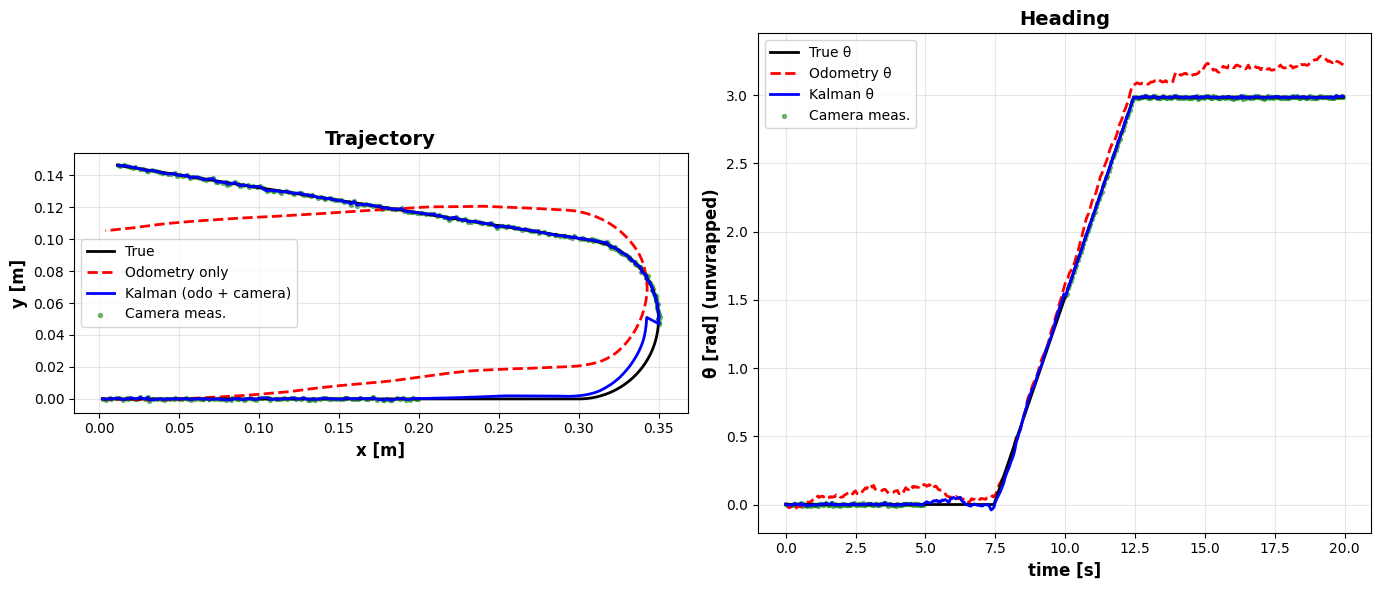

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Trajectory'}, xlabel='x [m]', ylabel='y [m]'>,
        <Axes: title={'center': 'Heading'}, xlabel='time [s]', ylabel='θ [rad] (unwrapped)'>],
       dtype=object))

In [10]:
import numpy as np

# Define Q (Process noise covariance)
dt = 0.05
axle_length = 0.093
sigma_v2 = 151.4387409522633e-6  # (m/s)^2
sigma_omega = 2 * sigma_v2 / axle_length**2
q_theta = sigma_omega * dt**2
q_pos = sigma_v2 * dt**2
Q = np.zeros((3, 3))
Q[0, 0] = q_pos
Q[1, 1] = q_pos
Q[2, 2] = q_theta

# Define R (Measurement noise covariance)
R = np.diag([
    0.1e-6,
    0.1e-6,
    (0.3 * np.pi / 180.0) ** 2,  # ~2° error on angle
])

# Define noise parameters
cam_noise_xy = 0.0005  # 0.5 mm std
cam_noise_th = 0.3     # degrees
wheel_noise_std = 0.012  # m/s
from kalman_demo import show_kalman_visualization

# With your custom Q and R
show_kalman_visualization(Q=Q, R=R, cam_noise_xy=cam_noise_xy, 
                          cam_noise_th=cam_noise_th, wheel_noise_std=wheel_noise_std)

In [11]:
# Kalman Filter Implementation
code_kalman = '''
import numpy as np


def _normalize_angle(angle):
    """Normalizes an angle to [-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def kalman_filter(
    x, u, y, P, Q, R, dt, r, L,
    
):
    """
    

    x : current state [x, y, theta]^T (shape (3,1))
    u : command [v_r, v_l, a_f]^T (shape (3,1))
    y : measurement [x_meas, y_meas, theta_meas]^T (shape (3,1))
    P : state covariance matrix (3x3)
    Q : model covariance (3x3) 
    R : measurement covariance (3x3)
    dt : time step (s)
    r : wheel radius (m) - not used directly here
    L : axle length in m
        """
    # State decomposition
    xk = x[0, 0]
    yk = x[1, 0]
    th = x[2, 0]

    # Commands (wheel speeds in m/s)
    v_thymio_r = u[0, 0]
    v_thymio_l = u[1, 0]

    # Convert wheel speeds -> linear/angular velocities
    v_cmd = (v_thymio_r + v_thymio_l) / 2.0
    w_cmd = (v_thymio_r - v_thymio_l) / L

    # --- RK2 method: use theta_mid for better accuracy ---
    theta_mid = th + (w_cmd * dt * 0.5)

    # Transition matrix F (linearization around theta_mid) for state [x, y, theta]
    F = np.array(
        [
            [1.0, 0.0, -v_cmd * np.sin(theta_mid) * dt],
            [0.0, 1.0,  v_cmd * np.cos(theta_mid) * dt],
            [0.0, 0.0, 1.0],
        ]
    )

    # Nonlinear transition function applied to x (with theta_mid), pose-only state
    x_apriori = np.array(
        [
            [xk + v_cmd * np.cos(theta_mid) * dt],
            [yk + v_cmd * np.sin(theta_mid) * dt],
            [th + w_cmd * dt],
        ]
    )
    # Normalize angle after prediction
    x_apriori[2, 0] = _normalize_angle(x_apriori[2, 0])

           

    # Observation matrix H: we measure [x, y, theta]
    H = np.array(
        [
            [1.0, 0.0, 0.0],
            [0.0, 1.0, 0.0],
            [0.0, 0.0, 1.0],
        ]
    )

    # ---------- Manual EKF using matrix multiplications (no FilterPy) ----------
    # A = F is the Jacobian of the motion model wrt state
    A = F

    # A priori covariance propagation
    P_apriori = A @ P @ A.T
    if Q is not None:
        P_apriori = P_apriori + Q

    # A priori state (already computed by nonlinear model)
    x_apriori_vec = x_apriori.reshape(3, 1)

    if y is not None:
        # Measurement vector
        z = y.reshape(3, 1).copy()

        # Innovation with special handling for angle
        theta_meas = z[2, 0]
        theta_pred = x_apriori_vec[2, 0]
        theta_innov = _normalize_angle(theta_meas - theta_pred)
        # Limit angular innovation to ~45° to avoid jumps
        max_innov = np.deg2rad(45.0)
        if abs(theta_innov) > max_innov:
            theta_innov = np.sign(theta_innov) * max_innov

        innovation = z - H @ x_apriori_vec
        innovation[2, 0] = theta_innov

        # Innovation covariance
        S = H @ P_apriori @ H.T + R
        K = P_apriori @ H.T @ np.linalg.inv(S)

        # A posteriori update
        x_new = x_apriori_vec + K @ innovation
        P_new = P_apriori - K @ H @ P_apriori
    else:
        # No measurement available: pure prediction
        x_new = x_apriori_vec
        P_new = P_apriori

    # Normalize angle in state
    x_new[2, 0] = _normalize_angle(x_new[2, 0])

    xk_new = x_new[0, 0]
    yk_new = x_new[1, 0]
    th_new = x_new[2, 0]  # already normalized

    # For velocities, we want to reflect **instantaneous motor measurement**,
    # i.e. what comes from wheel speeds (v_thymio_r, v_thymio_l).
    # So we directly reuse v_cmd and w_cmd calculated at the beginning.
    v_new = v_cmd
    w_new = w_cmd

    return xk_new, yk_new, th_new, v_new, w_new, P_new
'''

print("=== Kalman Filter Implementation ===")
print(code_kalman)
print("\nKey Features:")
print("- RK2 method improves accuracy for non-linear motion model")
print("- Process noise oriented in robot frame (more realistic)")
print("- Angle normalization prevents wrapping issues")
print("- Innovation limiting prevents large corrections from outliers")


=== Kalman Filter Implementation ===

import numpy as np


def _normalize_angle(angle):
    """Normalizes an angle to [-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def kalman_filter(
    x, u, y, P, Q, R, dt, r, L,
    
):
    """
    

    x : current state [x, y, theta]^T (shape (3,1))
    u : command [v_r, v_l, a_f]^T (shape (3,1))
    y : measurement [x_meas, y_meas, theta_meas]^T (shape (3,1))
    P : state covariance matrix (3x3)
    Q : model covariance (3x3) 
    R : measurement covariance (3x3)
    dt : time step (s)
    r : wheel radius (m) - not used directly here
    L : axle length in m
        """
    # State decomposition
    xk = x[0, 0]
    yk = x[1, 0]
    th = x[2, 0]

    # Commands (wheel speeds in m/s)
    v_thymio_r = u[0, 0]
    v_thymio_l = u[1, 0]

    # Convert wheel speeds -> linear/angular velocities
    v_cmd = (v_thymio_r + v_thymio_l) / 2.0
    w_cmd = (v_thymio_r - v_thymio_l) / L

    # --- RK2 method: use theta_mid for better accura

## Pure Pursuit Path Following

### File: `pure_pursuit.py`

Pure pursuit is a geometric path following algorithm that calculates the required steering angle to reach a target point on the path. The algorithm maintains a circle with the radius "look-ahead distance" (centered on the robot) and finds the intersection with a path segments that is closesed to the path goal. 

We chose Pure Pursuit because it is a relatively simple, yet, powerful algorithm to make the thymio follow a path. Another option (overkill) could have been a trajectory generation with a closed loop controler (e.g. PD cascade). 

**Look Ahead Distance**
The only Parameter to chose here is the Look Ahead Distance. It tells us the size of the radius that we draw around the thymio to search for intersections with the path. The larger the smoother the trajectory but it will start cutting corners. The smaller the more accurate with potential danger of oszillating behavior if we chose it too small.

**Key Features:**
- Finds the farthest valid intersection point along the path
- Prevents backward movement by validating intersection direction
- Automatically advances path index when robot passes waypoints
- Returns target point and turn error for control


The code is inspired from https://wiki.purduesigbots.com/software/control-algorithms/basic-pure-pursuit 

The code below runs a demo that graphically demonstrates how the purepursuit works. Later the Angle error will simply be substracted on one wheel and added on the other one. (That can happen in multiple different more or less suffisticated ways to implement a motion controler with the pure_pursuit error)


c:\Users\tomso\Desktop\Automne 2025 - MA1\Basics of mobile robotics\MOBILEPROJECT\Group_T03\pure_pursuit_demo.py:182: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  intersection_marker = plt.Circle(


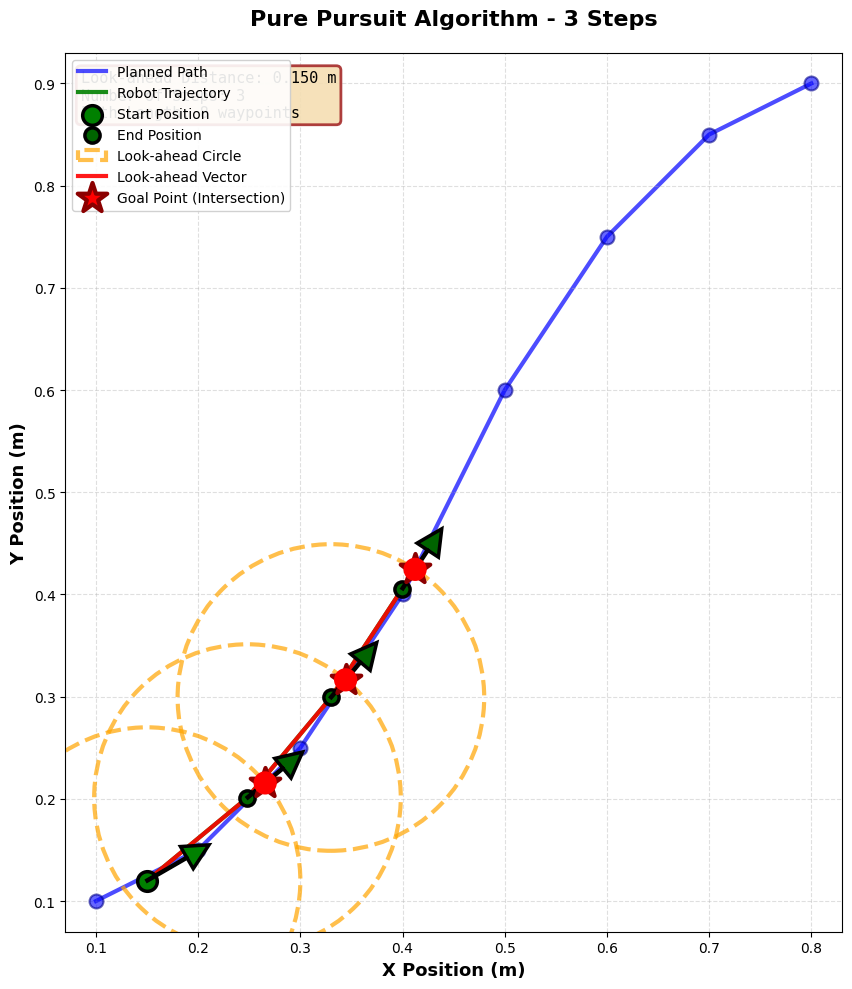

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'Pure Pursuit Algorithm - 3 Steps'}, xlabel='X Position (m)', ylabel='Y Position (m)'>)

In [12]:
from pure_pursuit_demo import show_pure_pursuit_visualization

show_pure_pursuit_visualization()

In [13]:
# Pure Pursuit Algorithm
code_pure_pursuit = '''
import math
from typing import List, Tuple

import numpy as np


def sgn(x: float) -> float:
    """Returns the sign of x (-1, 0, +1)."""
    if x > 0:
        return 1.0
    if x < 0:
        return -1.0
    return 0.0


def pt_to_pt_distance(p: Tuple[float, float], q: Tuple[float, float]) -> float:
    """Euclidean distance between two 2D points."""
    return math.hypot(p[0] - q[0], p[1] - q[1])


def pure_pursuit_step(
    path: List[Tuple[float, float]],
    current_pos: Tuple[float, float, float],
    lookAheadDis: float,
    LFindex: int,
) -> Tuple[Tuple[float, float], int, float]:
    """
    Pure pursuit implementation (TP version) in metric coordinates.

    - path: list of points (x, y) in meters
    - current_pos: (x, y, heading_deg) where heading is in degrees
    - lookAheadDis: look-ahead distance (m)
    - LFindex: index of last reached point in path

    Returns (goal_point(x,y), new_index, turnError_deg)
    """
    currentX = current_pos[0]
    currentY = current_pos[1]
    currentHeading = current_pos[2]  # in degrees

    lastFoundIndex = LFindex
    startingIndex = lastFoundIndex

    # Search for ALL possible intersections and take the farthest valid one
    best_goal_pt = None
    best_index = lastFoundIndex
    best_distance_along_path = -1.0  # Distance along path from start

    # Search for intersection between look-ahead circle and path segment
    for i in range(startingIndex, len(path) - 1):
        x1 = path[i][0] - currentX
        y1 = path[i][1] - currentY
        x2 = path[i + 1][0] - currentX
        y2 = path[i + 1][1] - currentY
        dx = x2 - x1
        dy = y2 - y1
        dr = math.hypot(dx, dy)
        D = x1 * y2 - x2 * y1
        discriminant = (lookAheadDis**2) * (dr**2) - D**2

        #discriminant >= 0 means there is at least one intersection (possibly two)
        if discriminant >= 0 and dr > 1e-9:
            sqrt_disc = math.sqrt(discriminant)
            sol_x1 = (D * dy + sgn(dy) * dx * sqrt_disc) / (dr**2)
            sol_x2 = (D * dy - sgn(dy) * dx * sqrt_disc) / (dr**2)
            sol_y1 = (-D * dx + abs(dy) * sqrt_disc) / (dr**2)
            sol_y2 = (-D * dx - abs(dy) * sqrt_disc) / (dr**2)

            sol_pt1 = (sol_x1 + currentX, sol_y1 + currentY)
            sol_pt2 = (sol_x2 + currentX, sol_y2 + currentY)

            # Check if intersection points are actually on the line segment (if path points are connected with a line it could be outside )
            def point_on_segment(pt, seg_start, seg_end, tolerance=1e-6):
                """Check if point is on line segment using parametric form."""
                dx_seg = seg_end[0] - seg_start[0]
                dy_seg = seg_end[1] - seg_start[1]
                seg_len_sq = dx_seg * dx_seg + dy_seg * dy_seg
                
                if seg_len_sq < 1e-12:  # Segment is too short
                    dist_to_start = pt_to_pt_distance(pt, seg_start)
                    dist_to_end = pt_to_pt_distance(pt, seg_end)
                    return dist_to_start < tolerance or dist_to_end < tolerance
                
                dx_pt = pt[0] - seg_start[0]
                dy_pt = pt[1] - seg_start[1]
                t = (dx_pt * dx_seg + dy_pt * dy_seg) / seg_len_sq
                
                if 0 <= t <= 1:
                    proj_x = seg_start[0] + t * dx_seg
                    proj_y = seg_start[1] + t * dy_seg
                    dist_to_line = math.hypot(pt[0] - proj_x, pt[1] - proj_y)
                    return dist_to_line < tolerance
                return False
            
            in1 = point_on_segment(sol_pt1, path[i], path[i + 1])
            in2 = point_on_segment(sol_pt2, path[i], path[i + 1])

            if in1 or in2:
                # Choose intersection point that's ahead of robot (farther along path)
                if in1 and in2:
                    # Calculate which point is farther along the path from path[i]
                    dist1_from_seg_start = pt_to_pt_distance(sol_pt1, path[i])
                    dist2_from_seg_start = pt_to_pt_distance(sol_pt2, path[i])
                    goalPt = sol_pt1 if dist1_from_seg_start > dist2_from_seg_start else sol_pt2
                else:
                    goalPt = sol_pt1 if in1 else sol_pt2

                # Check that intersection point is ahead of robot (don't go backward)
                # Calculate path direction vector
                path_dx = path[i + 1][0] - path[i][0]
                path_dy = path[i + 1][1] - path[i][1]
                path_len = math.hypot(path_dx, path_dy)
                
                if path_len > 1e-9:
                    # Vector from path[i] to goal point
                    goal_dx = goalPt[0] - path[i][0]
                    goal_dy = goalPt[1] - path[i][1]
                    
                    # Vector from robot to goal point
                    robot_to_goal_dx = goalPt[0] - currentX
                    robot_to_goal_dy = goalPt[1] - currentY
                    
                    # Check if goal is ahead: dot product of path direction and robot-to-goal should be positive
                    # OR if goal is on a segment ahead of the robot's current segment
                    dot_product = (path_dx * robot_to_goal_dx + path_dy * robot_to_goal_dy) / path_len
                    goal_ahead = dot_product > -0.01  # Small tolerance
                    
                    # Also check if goal is on a segment ahead of robot's current position
                    # by checking if distance along path from path[i] to goal > 0
                    goal_dist_along_seg = (goal_dx * path_dx + goal_dy * path_dy) / path_len
                    goal_on_ahead_segment = (i > lastFoundIndex) or (goal_dist_along_seg > -0.01)
                    
                    if goal_ahead or goal_on_ahead_segment:
                        # Calculate distance along path to this point
                        dist_along_path = 0.0
                        for j in range(i):
                            dist_along_path += pt_to_pt_distance(path[j], path[j + 1])
                        dist_along_path += pt_to_pt_distance(path[i], goalPt)
                        
                        # Keep farthest intersection along path
                        if dist_along_path > best_distance_along_path:
                            best_goal_pt = goalPt
                            # Update index: if robot is very close to path[i+1], advance index
                            if i < len(path) - 1:
                                dist_robot_to_next = pt_to_pt_distance((currentX, currentY), path[i + 1])
                                if dist_robot_to_next < 0.02:  # Robot very close to path[i+1]
                                    best_index = i + 1
                                else:
                                    best_index = i
                            else:
                                best_index = i
                            best_distance_along_path = dist_along_path
    
    if best_goal_pt is not None:
        goalPt = best_goal_pt
        lastFoundIndex = best_index
    else:
        # No new intersection found: check if we can advance index
        # If robot has passed next point, we can advance
        if lastFoundIndex < len(path) - 1:
            dist_to_next = pt_to_pt_distance(
                (currentX, currentY),
                path[lastFoundIndex + 1]
            )
            # If very close to next point (< lookahead), we can use it
            if dist_to_next < lookAheadDis * 0.5:
                lastFoundIndex = lastFoundIndex + 1
                goalPt = path[lastFoundIndex]
            else:
                goalPt = (path[lastFoundIndex][0], path[lastFoundIndex][1])
        else:
            # Already at last point
            goalPt = (path[lastFoundIndex][0], path[lastFoundIndex][1])
    
    # Force index advancement if robot has passed several points (before calculating angle)
    # (to avoid lf_index getting stuck, but only if we didn't find a better intersection)
    if best_goal_pt is None:  # Only advance if no intersection found
        while lastFoundIndex < len(path) - 1:
            dist_to_next = pt_to_pt_distance(
                (currentX, currentY),
                path[lastFoundIndex + 1]
            )
            # If robot is very close to next point, we can advance it
            if dist_to_next < lookAheadDis * 0.3:  # 30% of lookahead
                lastFoundIndex += 1
            else:
                break

    # Calculate absolute angle to goal point (in degrees)
    absTargetAngle = math.degrees(math.atan2(goalPt[1] - currentY, goalPt[0] - currentX))
    if absTargetAngle < 0:
        absTargetAngle += 360.0

    # Minimal angle error in degrees
    turnError = absTargetAngle - currentHeading
    if turnError > 180.0 or turnError < -180.0:
        turnError = -sgn(turnError) * (360.0 - abs(turnError))

    return goalPt, lastFoundIndex, turnError
'''

print("=== Pure Pursuit Algorithm ===")
print(code_pure_pursuit)
print("\nAlgorithm Steps:")
print("1. Search for circle-path intersections along remaining path")
print("2. Select farthest valid intersection (ahead of robot)")
print("3. Calculate angle error to target point")
print("4. Return target point and error for control")


=== Pure Pursuit Algorithm ===

import math
from typing import List, Tuple

import numpy as np


def sgn(x: float) -> float:
    """Returns the sign of x (-1, 0, +1)."""
    if x > 0:
        return 1.0
    if x < 0:
        return -1.0
    return 0.0


def pt_to_pt_distance(p: Tuple[float, float], q: Tuple[float, float]) -> float:
    """Euclidean distance between two 2D points."""
    return math.hypot(p[0] - q[0], p[1] - q[1])


def pure_pursuit_step(
    path: List[Tuple[float, float]],
    current_pos: Tuple[float, float, float],
    lookAheadDis: float,
    LFindex: int,
) -> Tuple[Tuple[float, float], int, float]:
    """
    Pure pursuit implementation (TP version) in metric coordinates.

    - path: list of points (x, y) in meters
    - current_pos: (x, y, heading_deg) where heading is in degrees
    - lookAheadDis: look-ahead distance (m)
    - LFindex: index of last reached point in path

    Returns (goal_point(x,y), new_index, turnError_deg)
    """
    currentX = current_

## Real-time Vision Tracking

### File: `vision_tracker.py`

During path execution, the system needs continuous pose updates from the camera. The `ThymioPoseTracker` class maintains an open camera stream and provides real-time pose measurements without the overhead of full recognition pipeline.

**Key Features:**
- Maintains persistent camera connection and homography
- Provides fast pose updates (x, y, theta) at each call
- Tracks goal position for dynamic path recalculation
- Can generate navigation snapshots for obstacle map updates


In [14]:
# Vision Tracker Implementation
code_vision_tracker = '''
class ThymioPoseTracker:
    """
    Manages a continuously open camera stream and allows reading Thymio pose
    (x, y, theta) in meters / radians at each call.
    """
    
    def __init__(self, cam_index=0, board_width_m=0.84, 
                 board_height_m=0.89, resolution_m=0.01):
        self.cap = cv2.VideoCapture(cam_index)
        
        # Stabilize autofocus
        for _ in range(10):
            self.cap.read()
        
        # Detect board once and compute homography
        ret, frame = self.cap.read()
        src_pts = detect_board_and_corners(frame)
        self.width_px = int(board_width_m / resolution_m)
        self.height_px = int(board_height_m / resolution_m)
        dst_pts = np.array([[0, 0], [self.width_px-1, 0],
                            [self.width_px-1, self.height_px-1],
                            [0, self.height_px-1]])
        self.homography = cv2.getPerspectiveTransform(src_pts, dst_pts)
        self.last_goal_m = None  # Track goal position
    
    def get_pose_m(self) -> Optional[Tuple[float, float, float]]:
        """Returns (x, y, theta) in meters / radians, or None if not detected."""
        ret, frame = self.cap.read()
        if not ret:
            return None
        
        # Apply homography (already computed)
        warped = cv2.warpPerspective(frame, self.homography, 
                                     (self.width_px, self.height_px))
        
        # Detect Thymio and orientation
        thymio_pos, _ = detect_thymio_green(warped, ...)
        if thymio_pos is None:
            return None
        
        theta, _ = detect_thymio_orientation(warped, thymio_pos, ...)
        if theta is None:
            return None
        
        # Convert to metric coordinates (origin at bottom-left)
        cx, cy = thymio_pos
        x_m = cx * self.resolution_m
        y_m = (self.height_px - 1 - cy) * self.resolution_m
        theta_world = -theta  # Calibration adjustment
        
        # Also detect goal for dynamic tracking
        goal_pos, _ = detect_goal_purple(warped, ...)
        if goal_pos is not None:
            gx, gy = goal_pos
            goal_x_m = gx * self.resolution_m
            goal_y_m = (self.height_px - 1 - gy) * self.resolution_m
            self.last_goal_m = (goal_x_m, goal_y_m)
        
        return x_m, y_m, theta_world
    
    def get_navigation_snapshot(self, red_cell_size_px=1):
        """Captures frame and reconstructs occupancy grid for path recalculation."""
        # Similar to run_recognition but uses existing camera/homography
        # Returns: occ_grid_coarse, thymio_cell, goal_cell
        ...
'''

print("=== Vision Tracker Class ===")
print(code_vision_tracker)
print("\nAdvantages:")
print("- Faster than full recognition (reuses homography)")
print("- Maintains camera connection (no reinitialization overhead)")
print("- Provides continuous pose updates for Kalman filter")
print("- Can generate snapshots for dynamic obstacle updates")


=== Vision Tracker Class ===

class ThymioPoseTracker:
    """
    Manages a continuously open camera stream and allows reading Thymio pose
    (x, y, theta) in meters / radians at each call.
    """
    
    def __init__(self, cam_index=0, board_width_m=0.84, 
                 board_height_m=0.89, resolution_m=0.01):
        self.cap = cv2.VideoCapture(cam_index)
        
        # Stabilize autofocus
        for _ in range(10):
            self.cap.read()
        
        # Detect board once and compute homography
        ret, frame = self.cap.read()
        src_pts = detect_board_and_corners(frame)
        self.width_px = int(board_width_m / resolution_m)
        self.height_px = int(board_height_m / resolution_m)
        dst_pts = np.array([[0, 0], [self.width_px-1, 0],
                            [self.width_px-1, self.height_px-1],
                            [0, self.height_px-1]])
        self.homography = cv2.getPerspectiveTransform(src_pts, dst_pts)
        self.last_goal_m =

### Coordinate System and Transformations

The system uses a consistent coordinate system throughout:

- **Image coordinates**: Top-left origin, (x, y) in pixels
- **World coordinates**: Bottom-left origin, (x, y) in meters
  - x-axis: rightward
  - y-axis: upward
  - theta: counterclockwise from x-axis (0 = pointing right)

The `grid_path_to_world_xy()` function in `motion_control.py` handles the conversion from grid cells to metric coordinates, ensuring consistency between path planning and execution.


In [15]:
# Coordinate transformation
code_coordinates = '''
def grid_path_to_world_xy(path, cell_size_m, grid_height=None):
    """
    Converts a path of cells (row, col) to points (x, y) in meters.
    
    Axis convention:
      - origin at bottom-left
      - x-axis to the right
      - y-axis upward
    """
    world_path_xy = []
    for r, c in path:
        x = (c + 0.5) * cell_size_m  # Center of cell
        # Invert vertical axis to have origin at bottom-left
        y = (grid_height - 1 - r + 0.5) * cell_size_m
        world_path_xy.append((x, y))
    return world_path_xy
'''

print("=== Coordinate Transformation ===")
print(code_coordinates)
print("\nThis ensures:")
print("- Path planning (grid cells) matches execution (metric coordinates)")
print("- Consistent coordinate system across all modules")
print("- Proper alignment between vision measurements and path following")


=== Coordinate Transformation ===

def grid_path_to_world_xy(path, cell_size_m, grid_height=None):
    """
    Converts a path of cells (row, col) to points (x, y) in meters.
    
    Axis convention:
      - origin at bottom-left
      - x-axis to the right
      - y-axis upward
    """
    world_path_xy = []
    for r, c in path:
        x = (c + 0.5) * cell_size_m  # Center of cell
        # Invert vertical axis to have origin at bottom-left
        y = (grid_height - 1 - r + 0.5) * cell_size_m
        world_path_xy.append((x, y))
    return world_path_xy


This ensures:
- Path planning (grid cells) matches execution (metric coordinates)
- Consistent coordinate system across all modules
- Proper alignment between vision measurements and path following


## System Integration and Data Flow

The following diagram shows how data flows through the system during execution:

```
┌─────────────────┐
│  Camera Input   │
└────────┬────────┘
         │
         ▼
┌─────────────────────────┐
│  Vision Recognition     │  ← Initial detection
│  (vision_recognition.py)│
└────────┬────────────────┘
         │ RecognitionResult
         ▼
┌─────────────────────────┐
│  Main Orchestration     │
│  (main.py)              │
└────────┬────────────────┘
         │
         ├─→ Navigation Map
         │
         ▼
┌─────────────────────────┐
│  A* Path Planning       │
│  (global_navigation.py) │
└────────┬────────────────┘
         │ Path (list of cells)
         ▼
┌─────────────────────────┐
│  Motion Control Loop    │  ← Continuous execution
│  (motion_control.py)    │
│                         │
│  ┌───────────────────┐  │
│  │ Vision Tracker    │  │  ← Real-time pose
│  │ (vision_tracker)  │  │
│  └────────┬──────────┘  │
│           │             │
│  ┌────────▼──────────┐  │
│  │ Kalman Filter     │  │  ← State estimation
│  │ (kalmanpy.py)     │  │
│  └────────┬──────────┘  │
│           │             │
│  ┌────────▼──────────┐  │
│  │ Pure Pursuit      │  │  ← Path following
│  │ (pure_pursuit.py) │  │
│  └────────┬──────────┘  │
│           │             │
│           ▼             │
│  ┌───────────────────┐  │
│  │ Motor Control     │  │  ← Robot commands
│  └───────────────────┘  │
└─────────────────────────┘
```

Each module has a specific role and communicates through well-defined interfaces.


## Key Design Decisions

### 1. Separation of Initial Detection and Continuous Tracking

**Initial Detection** (`vision_recognition.py`):
- Full pipeline: board detection, homography computation, all detections
- Used once at startup
- Provides complete environment map

**Continuous Tracking** (`vision_tracker.py`):
- Reuses precomputed homography
- Fast pose updates (only Thymio detection)
- Optimized for real-time performance

**Why**: This separation allows fast real-time updates while ensuring accurate initial mapping.

### 2. Kalman Filter for State Estimation

**Why Kalman Filter?**
- Combines odometry (high frequency, drifts over time) with vision (low frequency, absolute position)
- Provides smooth, accurate pose estimates even when vision is temporarily unavailable
- Handles sensor noise and uncertainties

**Implementation Details**:
- RK2 method for better accuracy in non-linear motion model
- Process noise oriented in robot frame (more physically meaningful)
- Innovation limiting prevents large corrections from outliers

### 3. Pure Pursuit for Path Following

**Why Pure Pursuit?**
- Smooth trajectory following (no sharp turns)
- Look-ahead distance provides stability
- Naturally handles path curvature

**Parameters**:
- Look-ahead distance: 14 cells (0.14m) - balances responsiveness and stability
- Automatically advances when robot passes waypoints

### 4. Reactive Obstacle Avoidance

**Why Reactive?**
- Handles dynamic obstacles not present during initial planning
- Complements global path planning
- Allows real-time adaptation to environment changes

**State Machine**:
- TURN_AWAY → FORWARD → CHECK → (recalculate path or loop)
- Ensures obstacle is fully cleared before resuming path


## Conclusion

This project successfully implements a complete autonomous navigation system for the Thymio robot, combining multiple advanced robotics techniques:

### Achievements

1. **Robust Vision System**: Reliable detection of robot, goal, and obstacles using color-based segmentation with perspective correction

2. **Optimal Path Planning**: A* algorithm efficiently finds shortest paths while handling obstacles and grid-based navigation

3. **Accurate State Estimation**: Extended Kalman Filter fuses odometry and vision for robust pose tracking, handling sensor noise and temporary vision loss

4. **Smooth Path Following**: Pure pursuit algorithm provides natural, stable trajectory tracking with configurable look-ahead distance

5. **Dynamic Adaptation**: Reactive obstacle avoidance and path recalculation enable navigation in changing environments

6. **System Integration**: Well-structured modular design with clear interfaces between components

### Technical Highlights

- **Modular Architecture**: Each component has a clear responsibility and can be tested independently
- **Real-time Performance**: System operates at 20 Hz with minimal latency
- **Robustness**: Handles edge cases like robot lifting (kidnapping), dynamic obstacles, and goal movement
- **Coordinate Consistency**: Unified coordinate system across all modules ensures accurate execution

### Future Improvements

Potential enhancements could include:
- Dynamic obstacle mapping during execution (currently uses initial map)
- More sophisticated avoidance strategies (e.g., potential fields)
- Adaptive look-ahead distance based on path curvature
- Multi-robot coordination capabilities
- Machine learning for improved color detection robustness

### Final Remarks

The system demonstrates a complete integration of computer vision, path planning, state estimation, and control theory to achieve autonomous navigation. The modular design facilitates maintenance, testing, and future extensions, making it a solid foundation for more advanced robotics applications.


## References

*[1] Mondada, F. Basics of mobile robotics. EPFL, Lausanne, Switzerland.*<br>
*[2] R. Labbe, "KalmanFilter," in FilterPy Documentation, 2024. [Online]. Available: https://filterpy.readthedocs.io/en/latest/kalman/KalmanFilter.html*<br>
*[3] Python Software Foundation, "heapq — Heap queue algorithm," Python Documentation, 2024. [Online]. Available: https://docs.python.org/3/library/heapq.html*

---

## Appendix: File Structure

```
project/
├── main.py                 # System entry point and orchestration
├── vision_recognition.py   # Initial computer vision detection
├── vision_tracker.py       # Real-time pose tracking
├── global_navigation.py    # A* path planning algorithm
├── motion_control.py       # Main control loop and robot interface
├── kalmanpy.py            # Extended Kalman Filter implementation
├── pure_pursuit.py        # Pure pursuit path following algorithm
├── color_tuner.py         # Development tool for color calibration
└── read_motor_speeds.py   # Development tool for sensor testing
```

**Core Files** (used in main pipeline):
- `main.py` - Orchestrates the entire system
- `vision_recognition.py` - Initial environment detection
- `vision_tracker.py` - Continuous pose tracking
- `global_navigation.py` - Path planning
- `motion_control.py` - Motion control and robot interface
- `kalmanpy.py` - State estimation
- `pure_pursuit.py` - Path following control

**Development Tools** (not used in main pipeline):
- `color_tuner.py` - HSV color calibration utility
- `read_motor_speeds.py` - Motor sensor testing tool

---

*End of Report*
